In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import pandas as pd
from pathlib import Path


In [2]:
path = "/home/macke/mgloeckler90/dmri/results/updated5_b3s_2_4_6_128"

def load_or_na(p):
    p = Path(p)
    if p.exists():
        return nib.load(str(p)).get_fdata()
    return None

syn_eval = load_or_na(f"{path}/synthetic_eval/metric_ess.nii.gz")
syn_eval_long = load_or_na(f"{path}/synthetic_eval_long/metric_ess.nii.gz")
syn_ksd_short = load_or_na(f"{path}/synthetic_eval/metric_ksd.nii.gz")
syn_ksd_long = load_or_na(f"{path}/synthetic_eval_long/metric_ksd.nii.gz")

syn_rmse_short = load_or_na(f"{path}/synthetic_eval/error_reconstruction.nii.gz")
syn_rmse_long = load_or_na(f"{path}/synthetic_eval_long/error_reconstruction.nii.gz")

real_ess = load_or_na(f"{path}/data_eval_b3s/metric_ess.nii.gz")
real_ksd = load_or_na(f"{path}/data_eval_b3s/metric_ksd.nii.gz")
real_rmse = load_or_na(f"{path}/data_eval_b3s/error_reconstruction.nii.gz")

real_ess_b2s = load_or_na(f"{path}/data_eval_b2s/metric_ess.nii.gz")
real_ksd_b2s = load_or_na(f"{path}/data_eval_b2s/metric_ksd.nii.gz")
real_rmse_b2s = load_or_na(f"{path}/data_eval_b2s/error_reconstruction.nii.gz")

real_ess_b1s = load_or_na(f"{path}/data_eval_b1s/metric_ess.nii.gz")
real_ksd_b1s = load_or_na(f"{path}/data_eval_b1s/metric_ksd.nii.gz")
real_rmse_b1s = load_or_na(f"{path}/data_eval_b1s/error_reconstruction.nii.gz")


In [3]:
brain_mask_small = nib.load('/home/macke/mgloeckler90/dmri/data/data/nodif_brain_mask.nii.gz').get_fdata().astype(bool)
brain_mask_long = nib.load('/home/macke/mgloeckler90/dmri/data/new_data/nodif_brain_mask.nii.gz').get_fdata().astype(bool)

In [4]:
from scipy.ndimage import binary_erosion
brain_mask_small = binary_erosion(brain_mask_small, iterations=2)
brain_mask_long = binary_erosion(brain_mask_long, iterations=2)

In [5]:
def exclude_outliers(ksd, q=0.99):
    if ksd is None:
        return None
    threshold = np.quantile(ksd[brain_mask_small], q)
    ksd_filtered = np.copy(ksd)
    ksd_filtered[ksd > threshold] = threshold
    return ksd_filtered

def exclude_outliers_syn(ksd, q=0.99):
    if ksd is None:
        return None
    threshold = np.quantile(ksd, q)
    ksd_filtered = np.copy(ksd)
    ksd_filtered[ksd > threshold] = threshold
    return ksd_filtered


In [6]:
# Summary stats (median, 10th, 90th percentiles)

def qstats(arr, mask=None):
    if arr is None:
        return np.nan, np.nan, np.nan
    data = arr[mask] if mask is not None else arr
    if data.size == 0:
        return np.nan, np.nan, np.nan
    median = np.nanmedian(data)
    q10, q90 = np.nanquantile(data, [0.1, 0.9])
    return median, q10, q90

rows = []

# Synthetic
ess_median, ess_q10, ess_q90 = qstats(syn_eval)
rows.append({"dataset": "synthetic_short", "metric": "ESS", "median": ess_median, "q10": ess_q10, "q90": ess_q90})

ess_long_median, ess_long_q10, ess_long_q90 = qstats(syn_eval_long)
rows.append({"dataset": "synthetic_long", "metric": "ESS", "median": ess_long_median, "q10": ess_long_q10, "q90": ess_long_q90})

ksd_filtered_syn = exclude_outliers_syn(syn_ksd_short)
ksd_median, ksd_q10, ksd_q90 = qstats(ksd_filtered_syn)
rows.append({"dataset": "synthetic_short", "metric": "KSD", "median": ksd_median, "q10": ksd_q10, "q90": ksd_q90})

ksd_long_filtered_syn = exclude_outliers_syn(syn_ksd_long)
ksd_long_median, ksd_long_q10, ksd_long_q90 = qstats(ksd_long_filtered_syn)
rows.append({"dataset": "synthetic_long", "metric": "KSD", "median": ksd_long_median, "q10": ksd_long_q10, "q90": ksd_long_q90})

rmse_short_median, rmse_short_q10, rmse_short_q90 = qstats(syn_rmse_short)
rows.append({"dataset": "synthetic_short", "metric": "RMSE", "median": rmse_short_median, "q10": rmse_short_q10, "q90": rmse_short_q90})

rmse_long_median, rmse_long_q10, rmse_long_q90 = qstats(syn_rmse_long)
rows.append({"dataset": "synthetic_long", "metric": "RMSE", "median": rmse_long_median, "q10": rmse_long_q10, "q90": rmse_long_q90})

# Real (masked)
real_ess_b3s_median, real_ess_b3s_q10, real_ess_b3s_q90 = qstats(real_ess, brain_mask_small)
rows.append({"dataset": "real_b3s", "metric": "ESS", "median": real_ess_b3s_median, "q10": real_ess_b3s_q10, "q90": real_ess_b3s_q90})

real_ess_b2s_median, real_ess_b2s_q10, real_ess_b2s_q90 = qstats(real_ess_b2s, brain_mask_small)
rows.append({"dataset": "real_b2s", "metric": "ESS", "median": real_ess_b2s_median, "q10": real_ess_b2s_q10, "q90": real_ess_b2s_q90})

real_ess_b1s_median, real_ess_b1s_q10, real_ess_b1s_q90 = qstats(real_ess_b1s, brain_mask_small)
rows.append({"dataset": "real_b1s", "metric": "ESS", "median": real_ess_b1s_median, "q10": real_ess_b1s_q10, "q90": real_ess_b1s_q90})

real_ksd_filtered = exclude_outliers(real_ksd)
real_ksd_b2s_filtered = exclude_outliers(real_ksd_b2s)
real_ksd_b1s_filtered = exclude_outliers(real_ksd_b1s)

real_ksd_b3s_median, real_ksd_b3s_q10, real_ksd_b3s_q90 = qstats(real_ksd_filtered, brain_mask_small)
rows.append({"dataset": "real_b3s", "metric": "KSD", "median": real_ksd_b3s_median, "q10": real_ksd_b3s_q10, "q90": real_ksd_b3s_q90})

real_ksd_b2s_median, real_ksd_b2s_q10, real_ksd_b2s_q90 = qstats(real_ksd_b2s_filtered, brain_mask_small)
rows.append({"dataset": "real_b2s", "metric": "KSD", "median": real_ksd_b2s_median, "q10": real_ksd_b2s_q10, "q90": real_ksd_b2s_q90})

real_ksd_b1s_median, real_ksd_b1s_q10, real_ksd_b1s_q90 = qstats(real_ksd_b1s_filtered, brain_mask_small)
rows.append({"dataset": "real_b1s", "metric": "KSD", "median": real_ksd_b1s_median, "q10": real_ksd_b1s_q10, "q90": real_ksd_b1s_q90})

real_rmse_b3s_median, real_rmse_b3s_q10, real_rmse_b3s_q90 = qstats(real_rmse, brain_mask_small)
rows.append({"dataset": "real_b3s", "metric": "RMSE", "median": real_rmse_b3s_median, "q10": real_rmse_b3s_q10, "q90": real_rmse_b3s_q90})

real_rmse_b2s_median, real_rmse_b2s_q10, real_rmse_b2s_q90 = qstats(real_rmse_b2s, brain_mask_small)
rows.append({"dataset": "real_b2s", "metric": "RMSE", "median": real_rmse_b2s_median, "q10": real_rmse_b2s_q10, "q90": real_rmse_b2s_q90})

real_rmse_b1s_median, real_rmse_b1s_q10, real_rmse_b1s_q90 = qstats(real_rmse_b1s, brain_mask_small)
rows.append({"dataset": "real_b1s", "metric": "RMSE", "median": real_rmse_b1s_median, "q10": real_rmse_b1s_q10, "q90": real_rmse_b1s_q90})

summary_df = pd.DataFrame(rows)
summary_df


,dataset,metric,median,q10,q90
0,synthetic_short,ESS,0.615219,0.097736,0.962191
1,synthetic_long,ESS,0.577778,0.083735,0.978773
2,synthetic_short,KSD,0.303584,0.000000,11.752600
3,synthetic_long,KSD,0.141294,0.000000,11.866746
4,synthetic_short,RMSE,0.019935,0.011774,0.075876
5,synthetic_long,RMSE,0.019648,0.011628,0.075704
6,real_b3s,ESS,0.276185,0.070184,0.621429
7,real_b2s,ESS,0.384137,0.052621,0.684504
8,real_b1s,ESS,0.177375,0.020962,0.694982
9,real_b3s,KSD,0.062003,0.000000,0.758170


In [7]:
# Quantile-based summary printed above.


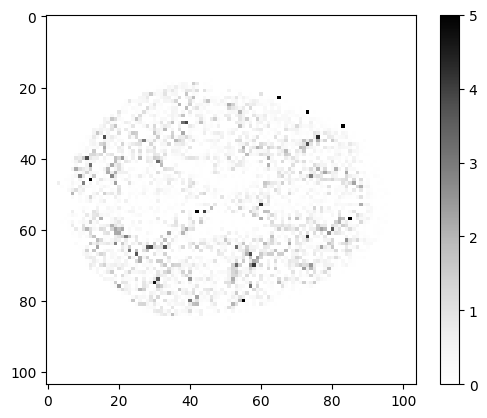

In [8]:
plt.imshow(real_ksd[:, :, 40],interpolation='nearest', vmax=5., cmap='Greys')
plt.colorbar()

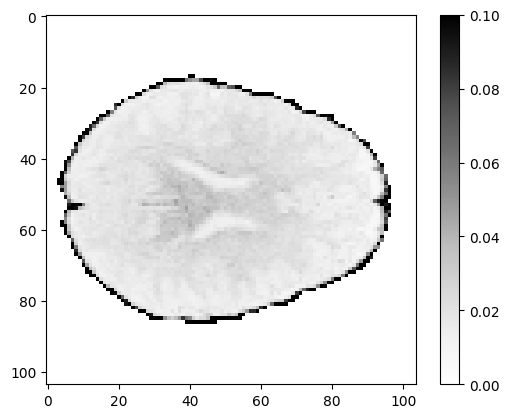

In [9]:
plt.imshow(real_rmse[:, :, 40],interpolation='nearest', vmax=0.1, cmap="Greys")
plt.colorbar()